# Machine Learning & Modeling I

Welcome! This notebook introduces the fundamental concepts of Modeling and Machine Learning, which is about using that data to make predictions or find hidden structures.

By the end of this notebook, you will be able to:
*   Define modeling and machine learning at a high level.
*   Distinguish between supervised and unsupervised learning.
*   Understand the risks of overfitting and the importance of train/test splits.
*   Evaluate model performance using accuracy, precision, and confusion matrices.


### What is Modeling and Machine Learning?
Modeling is the process of creating a simplified representation of reality. We create mathematical models to describe relationships between variables. Machine Learning is the practice of using algorithms to "learn" these models from data rather than following a rigid set of hand-written rules.

Machine learning is intricate and non-linear, as it adapts based on the patterns it finds in the data you provide.

**Example Use Cases:**

* Spam Detection: Classifying an email as "Spam" or "Ham."

* Price Prediction: Estimating the market value of a home based on its location and size.

* Medical Diagnosis: Identifying anomalies in X-ray images.

### Types of Machine Learning
Machine Learning tasks are generally categorized by the "supervision" they receive during training.

Supervised Learning: The model is trained on "labeled" data (data where the answer is already known).

* **Regression:** Predicting a continuous number (e.g., temperature).

* **Classification:** Predicting a category (e.g., "Cat" vs "Dog").

Unsupervised Learning: The model looks for patterns in "unlabeled" data.

* **Clustering:** Grouping similar data points together without knowing the group names in advance.

To pick a model, if you have a specific target variable you want to predict, go with a supervised model. If you are trying to discover how your data naturally segments or simplifies, go with an unsupervised model.

For our example use cases above, we would use:
* Spam Detection: Classification, since we are predicting categories "Ham" or "Spam."
* Price Prediction: Regression, since the market values of homes are a continuous number.
* Medical Diagnosis: Clustering

### Training Models

When we "train" a model, we are asking it to find the best mathematical parameters to fit our data. However, there is a major risk called overfitting.

**Overfitting:** When a model is too complex and learns the "noise" or random outliers in your training data. It will look like it has 100% accuracy on your training set but will fail on new, real-world data.

**The Train/Test Split:** To prevent this, we split our data. We train on 80% and keep 20% "hidden" to test the model's true performance later.

Here's how to perform a train/test split using the sci-kit learn library.


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Create a dummy dataset
data = pd.DataFrame({
    'feature_hourse_power': np.random.randint(100, 500, 100),
    'target_price': np.random.randint(20000, 80000, 100)
})

# Splitting data: 80% for training, 20% for testing
train, test = train_test_split(data, test_size=0.2, random_state=42)

print(f"Full dataset size: {len(data)}")
print(f"Training set size: {len(train)}")
print(f"Testing set size: {len(test)}")

Full dataset size: 100
Training set size: 80
Testing set size: 20


### Evaluating Models

In classification, simply saying a model is "90% accurate" can be misleading, especially if your data is imbalanced (e.g., 99% of emails are Ham, and only 1% are Spam). We need more granular tools to understand how the model is failing.

#### The Confusion Matrix

There are 4 different different classifications that our model might make:

* True positive: correctly classify a positive point as being positive
* True negative: correctly classify a negative point as being negative
* False positive: incorrectly classify a negative point as being positive
* False negative: incorrectly classify a positive point as being negative

These are summarized in the **confusion matrix** below.
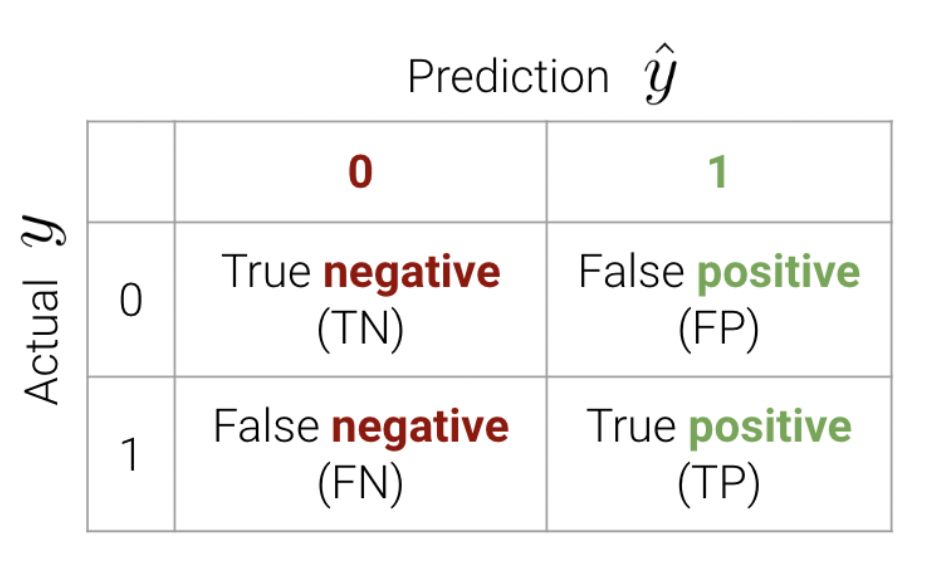

###Ways to evaluate models

**Accuracy:** $(TP + TN) / \text{Total}$. The overall correct percentage.

**Precision:** $TP / (TP + FP)$. Of all predicted positives, how many were actually positive? Penalizes false positives.

**Recall (Sensitivity):** $TP / (TP + FN)$. Of all actual positives, how many did we catch? Penalizes false negatives.

###Example calculations

Imagine we have 100 emails, where 5 are Spam (1) and 95 are Ham (0).

**Model A (uses a lazy model):** Predicts "Ham" for every single email.

* **Accuracy:** 95/100 = 95%
* Do you notice a pitfall of using accuracy in this case? A 95% accuracy rate sounds great, but it caught 0% of actual spam!

* **Recall:** 0/5 = 0%

**Model B (uses an overly paranoid model):** Predicts "Spam" for every single email.

* **Accuracy:** 5/100 = 5%
* The accuracy percentage looks pretty bad, which in the case of this model, is pretty reflective of how good the model is!
* **Recall:** 5/5 = 100%
* Although 100% recall looks like a perfect model and caught every spam email, it ruined the user experience by marking everything as spam.